# 10 — Ensemble

Combina las predicciones de los tres modelos usando un **weighted blend optimizado con Optuna** sobre predicciones OOF (out-of-fold), sin overfitting al train.

**Archivos necesarios** (generados por los notebooks anteriores):
- `submissions/oof_tab.csv` — OOF del modelo tabular (07)
- `submissions/oof_img.csv` — OOF del modelo de imágenes (08, CLIP)
- `submissions/oof_txt.csv` — OOF del modelo de texto (09, Sentence Transformers)
- `submissions/test_lgbm_07.csv` — predicciones test del tabular
- `submissions/test_image_08.csv` — predicciones test de imágenes
- `submissions/test_text_09.csv` — predicciones test de texto


Lo que hace cada sección
Sección	    Qué hace

3	Carga los 3 OOF + precios reales del train

4	Muestra el MAPE individual de cada modelo + pesos "naive" (1/MAPE)

5	Optuna (200 trials) busca w_tab, w_img, w_txt que minimizan MAPE sobre OOF

6	Gráfico comparativo: barras de cada modelo vs ensemble en rojo

7	Aplica los pesos óptimos a las predicciones de test

8	Guarda Grupo_10_ensemble.csv

## 1. Imports

In [1]:
!pip install optuna --quiet

In [2]:
import os
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

if not os.path.exists('data/tabular/train_processed.csv'):
    os.chdir('..')

os.makedirs('submissions', exist_ok=True)
print('Imports OK')

c:\Users\u581537.TELECOM.000\.conda\envs\ldi2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## 2. Configuración

In [3]:
# Archivos OOF (predicciones sobre train, usadas para optimizar pesos)
OOF_TAB = 'submissions/oof_tab.csv'
OOF_IMG = 'submissions/oof_img.csv'
OOF_TXT = 'submissions/oof_txt.csv'

# Archivos de predicciones sobre test
TEST_TAB = 'submissions/test_lgbm_07.csv'
TEST_IMG = 'submissions/test_image_08.csv'
TEST_TXT = 'submissions/test_text_09.csv'

SUBMISSION = 'submissions/Grupo_10_ensemble.csv'
N_TRIALS   = 200

PRICE_COL = 'lastSoldPrice_hpi_adjusted'

## 3. Carga de predicciones OOF

In [4]:
train = pd.read_csv('data/tabular/train_processed.csv')[['zpid', PRICE_COL]]

oof_tab = pd.read_csv(OOF_TAB).rename(columns={'oof_pred_price': 'tab'})
oof_img = pd.read_csv(OOF_IMG).rename(columns={'oof_pred_price': 'img'})
oof_txt = pd.read_csv(OOF_TXT).rename(columns={'oof_pred_price': 'txt'})

oof = (train
       .merge(oof_tab, on='zpid', how='inner')
       .merge(oof_img, on='zpid', how='inner')
       .merge(oof_txt, on='zpid', how='inner'))

print(f'OOF alineado: {len(oof)} filas')
print(f'Columnas: {list(oof.columns)}')

OOF alineado: 10263 filas
Columnas: ['zpid', 'lastSoldPrice_hpi_adjusted', 'tab', 'img', 'txt']


## 4. MAPE individual de cada modelo

In [5]:
true_price = oof[PRICE_COL].values

def mape(pred, true):
    return np.mean(np.abs((true - pred) / true)) * 100

mape_tab = mape(oof['tab'].values, true_price)
mape_img = mape(oof['img'].values, true_price)
mape_txt = mape(oof['txt'].values, true_price)

print('MAPE OOF por modelo:')
print(f'  Tabular:  {mape_tab:.2f}%')
print(f'  Imagenes: {mape_img:.2f}%')
print(f'  Texto:    {mape_txt:.2f}%')
print()
print('Peso naive (proporcional a 1/MAPE):')
total_inv = 1/mape_tab + 1/mape_img + 1/mape_txt
print(f'  Tabular:  {(1/mape_tab)/total_inv:.3f}')
print(f'  Imagenes: {(1/mape_img)/total_inv:.3f}')
print(f'  Texto:    {(1/mape_txt)/total_inv:.3f}')

MAPE OOF por modelo:
  Tabular:  25.78%
  Imagenes: 61.58%
  Texto:    45.47%

Peso naive (proporcional a 1/MAPE):
  Tabular:  0.504
  Imagenes: 0.211
  Texto:    0.286


## 5. Optuna — optimización de pesos sobre OOF

Optuna busca los pesos `(w_tab, w_img, w_txt)` que minimizan el MAPE sobre las predicciones OOF.
Como las OOF son predicciones honestas (el modelo no vio esos datos en entrenamiento), no hay overfitting.

In [6]:
tab_oof = oof['tab'].values
img_oof = oof['img'].values
txt_oof = oof['txt'].values


def objective(trial):
    w_tab = trial.suggest_float('w_tab', 0.0, 1.0)
    w_img = trial.suggest_float('w_img', 0.0, 1.0)
    w_txt = trial.suggest_float('w_txt', 0.0, 1.0)

    total = w_tab + w_img + w_txt
    if total == 0:
        return 999.0

    blend = (w_tab * tab_oof + w_img * img_oof + w_txt * txt_oof) / total
    return mape(blend, true_price)


study = optuna.create_study(direction='minimize', study_name='ensemble')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_params
total_w = best['w_tab'] + best['w_img'] + best['w_txt']
W_TAB = best['w_tab'] / total_w
W_IMG = best['w_img'] / total_w
W_TXT = best['w_txt'] / total_w

best_blend = W_TAB * tab_oof + W_IMG * img_oof + W_TXT * txt_oof
mape_ensemble = mape(best_blend, true_price)

print(f'\nPesos optimos (normalizados):')
print(f'  Tabular:  {W_TAB:.3f}')
print(f'  Imagenes: {W_IMG:.3f}')
print(f'  Texto:    {W_TXT:.3f}')
print(f'\nMAPE OOF ensemble: {mape_ensemble:.2f}%')

Best trial: 143. Best value: 25.785: 100%|██████████| 200/200 [00:01<00:00, 105.49it/s] 


Pesos optimos (normalizados):
  Tabular:  0.998
  Imagenes: 0.001
  Texto:    0.001

MAPE OOF ensemble: 25.79%


## 6. Comparación de resultados

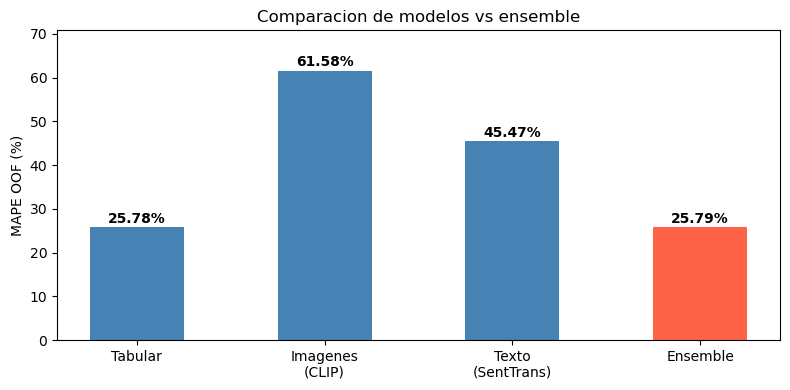


Mejora del ensemble sobre el mejor modelo individual: -0.00 puntos


In [7]:
modelos = ['Tabular', 'Imagenes\n(CLIP)', 'Texto\n(SentTrans)', 'Ensemble']
mapes   = [mape_tab, mape_img, mape_txt, mape_ensemble]
colores = ['steelblue', 'steelblue', 'steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(modelos, mapes, color=colores, width=0.5)
ax.set_ylabel('MAPE OOF (%)')
ax.set_title('Comparacion de modelos vs ensemble')
ax.set_ylim(0, max(mapes) * 1.15)
for bar, val in zip(bars, mapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nMejora del ensemble sobre el mejor modelo individual: {min(mape_tab, mape_img, mape_txt) - mape_ensemble:.2f} puntos')

## 7. Aplicar pesos a predicciones de test

In [8]:
test_base = pd.read_csv('data/tabular/test_processed.csv')[['zpid']]

pred_tab = pd.read_csv(TEST_TAB).rename(columns={'predicted_price': 'tab'})
pred_img = pd.read_csv(TEST_IMG).rename(columns={'predicted_price': 'img'})
pred_txt = pd.read_csv(TEST_TXT).rename(columns={'predicted_price': 'txt'})

test_preds = (test_base
              .merge(pred_tab, on='zpid', how='left')
              .merge(pred_img, on='zpid', how='left')
              .merge(pred_txt, on='zpid', how='left'))

# Rellenar NaN con la mediana de cada modelo (por si algun zpid no tiene prediccion)
for col in ['tab', 'img', 'txt']:
    test_preds[col] = test_preds[col].fillna(test_preds[col].median())

test_preds['predicted_price'] = (
    W_TAB * test_preds['tab'] +
    W_IMG * test_preds['img'] +
    W_TXT * test_preds['txt']
)

print(f'Test alineado: {len(test_preds)} filas')
print(f'NaN en prediccion final: {test_preds["predicted_price"].isna().sum()}')

Test alineado: 5038 filas
NaN en prediccion final: 0


## 8. Submission

In [9]:
submission = test_preds[['zpid', 'predicted_price']]
submission.to_csv(SUBMISSION, index=False)
print(f'Guardado {SUBMISSION} ({len(submission)} filas)')
print(f'\nResumen pesos finales:')
print(f'  Tabular:  {W_TAB:.3f}')
print(f'  Imagenes: {W_IMG:.3f}')
print(f'  Texto:    {W_TXT:.3f}')
print(f'  MAPE OOF ensemble: {mape_ensemble:.2f}%')
submission.head()

Guardado submissions/Grupo_10_ensemble.csv (5038 filas)

Resumen pesos finales:
  Tabular:  0.998
  Imagenes: 0.001
  Texto:    0.001
  MAPE OOF ensemble: 25.79%


,zpid,predicted_price
0,1009018,506030.049458
1,1001436,666420.210793
2,1010988,491852.945755
3,1002184,271362.222397
4,1015717,326097.827040
